In [42]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.01):
        self.weights = np.zeros(num_inputs + 1)
        self.learning_rate = learning_rate
        self.errors_per_epoch = []

    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    def activation(self, z):
        return 1 if z >= 0 else 0

    def predict(self, inputs):
        z = self.linear(inputs)
        return self.activation(z)

    def train(self, x_i, y_i):
        prediction = self.predict(x_i)
        error = y_i - prediction

        self.weights[1:] += self.learning_rate * error * x_i
        self.weights[0] += self.learning_rate * error

        return abs(error)

    def fit(self, X, y, num_epochs=10, verbose=True):

        for epoch in range(num_epochs):
            total_error = 0

            for x_i, y_i in zip(X, y):
                total_error += self.train(x_i, y_i)

            self.errors_per_epoch.append(total_error)

            if verbose:
                print(f"Epoch {epoch+1}, Error={total_error}")

    def evaluate(self, X, y):

        predictions = [self.predict(x) for x in X]
        accuracy = np.mean(predictions == y)

        print(f"Akurasi = {accuracy*100:.2f}%")
        return accuracy

    def plot_errors(self):
        plt.plot(self.errors_per_epoch, marker='o')
        plt.title("Total Error per Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Total Error")
        plt.grid(True)
        plt.show()

    def plot_decision_boundary(self, X, y):

        if X.shape[1] != 2:
            print("Visualisasi hanya didukung untuk data 2 dimensi.")
            return

        x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
        y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

        xx, yy = np.meshgrid(
            np.linspace(x_min,x_max,100),
            np.linspace(y_min,y_max,100)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]

        preds = np.array([self.predict(pt) for pt in grid])
        preds = preds.reshape(xx.shape)

        plt.contourf(xx, yy, preds, alpha=0.3, cmap='coolwarm')
        plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
        plt.title("Decision Boundary")
        plt.show()

### AND Gate

AND Gate Predictions:
[0 0] => 0
[0 1] => 0
[1 0] => 0
[1 1] => 1


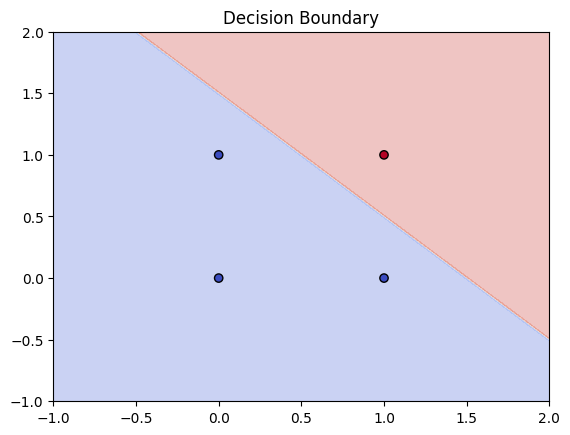

In [43]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

and_model = Perceptron(num_inputs=2)
and_model.weights = np.array([-1.5,1.0,1.0])

print("AND Gate Predictions:")
for x in X:
    print(f"{x} => {and_model.predict(x)}")

and_model.plot_decision_boundary(X,y_and)

### OR Gate

OR Gate Predictions:
[0 0] => 0
[0 1] => 1
[1 0] => 1
[1 1] => 1


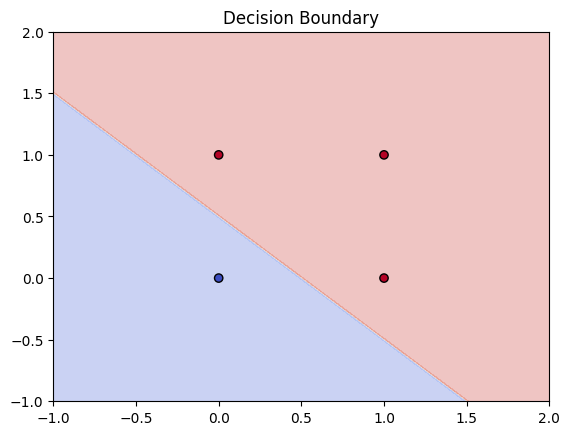

In [44]:
y_or = np.array([0,1,1,1])

or_model = Perceptron(num_inputs=2)
or_model.weights = np.array([-0.5,1.0,1.0])

print("OR Gate Predictions:")
for x in X:
    print(f"{x} => {or_model.predict(x)}")

or_model.plot_decision_boundary(X,y_or)

### NOT Gate

In [45]:
X_not = np.array([
    [0],
    [1]
])

y_not = np.array([1,0])

not_model = Perceptron(num_inputs=1)
not_model.weights = np.array([0.5,-1.0])

print("NOT Gate Predictions:")
for x in X_not:
    print(f"{x} => {not_model.predict(x)}")

NOT Gate Predictions:
[0] => 1
[1] => 0


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [47]:
# Membaca dataset
df = pd.read_csv("iris.csv")

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [48]:
print(df.info())

print("\nUkuran Dataset:")
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Ukuran Dataset:
(150, 6)


In [49]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.head())
print(y.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0   1            5.1           3.5            1.4           0.2
1   2            4.9           3.0            1.4           0.2
2   3            4.7           3.2            1.3           0.2
3   4            4.6           3.1            1.5           0.2
4   5            5.0           3.6            1.4           0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (120, 5)
Data Testing  : (30, 5)


In [51]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
sigmoid_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='logistic',
    max_iter=1000,
    random_state=42
)

sigmoid_model.fit(X_train, y_train)

y_pred_sigmoid = sigmoid_model.predict(X_test)

sigmoid_acc = accuracy_score(
    y_test,
    y_pred_sigmoid
)

print("Accuracy Sigmoid =", sigmoid_acc)

Accuracy Sigmoid = 1.0


c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
tanh_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='tanh',
    max_iter=1000,
    random_state=42
)

tanh_model.fit(X_train, y_train)

y_pred_tanh = tanh_model.predict(X_test)

tanh_acc = accuracy_score(
    y_test,
    y_pred_tanh
)

print("Accuracy Tanh =", tanh_acc)

Accuracy Tanh = 1.0


c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [54]:
relu_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=1000,
    random_state=42
)

relu_model.fit(X_train, y_train)

y_pred_relu = relu_model.predict(X_test)

relu_acc = accuracy_score(
    y_test,
    y_pred_relu
)

print("Accuracy ReLU =", relu_acc)

Accuracy ReLU = 1.0


In [55]:
print("\nLoss Sigmoid =", sigmoid_model.loss_)
print("Loss Tanh    =", tanh_model.loss_)
print("Loss ReLU    =", relu_model.loss_)


Loss Sigmoid = 0.17259511789956877
Loss Tanh    = 0.06059125757775488
Loss ReLU    = 0.049204137253066736


In [56]:
results_df = pd.DataFrame({
    "Activation Function": [
        "Sigmoid",
        "Tanh",
        "ReLU"
    ],
    "Accuracy": [
        sigmoid_acc,
        tanh_acc,
        relu_acc
    ],
    "Loss": [
        sigmoid_model.loss_,
        tanh_model.loss_,
        relu_model.loss_
    ]
})

print("\nTabel Perbandingan")
print(results_df)


Tabel Perbandingan
  Activation Function  Accuracy      Loss
0             Sigmoid       1.0  0.172595
1                Tanh       1.0  0.060591
2                ReLU       1.0  0.049204


In [57]:
results_df = pd.DataFrame({
    "Activation Function": [
        "Sigmoid",
        "Tanh",
        "ReLU"
    ],
    "Accuracy": [
        sigmoid_acc,
        tanh_acc,
        relu_acc
    ],
    "Loss": [
        sigmoid_model.loss_,
        tanh_model.loss_,
        relu_model.loss_
    ]
})

print("\nTabel Perbandingan")
print(results_df)


Tabel Perbandingan
  Activation Function  Accuracy      Loss
0             Sigmoid       1.0  0.172595
1                Tanh       1.0  0.060591
2                ReLU       1.0  0.049204


In [58]:
best = results_df.loc[
    results_df["Loss"].idxmin()
]

print("\nAktivasi Terbaik")
print("Fungsi Aktivasi :", best["Activation Function"])
print("Accuracy        :", best["Accuracy"])
print("Loss            :", best["Loss"])


Aktivasi Terbaik
Fungsi Aktivasi : ReLU
Accuracy        : 1.0
Loss            : 0.049204137253066736


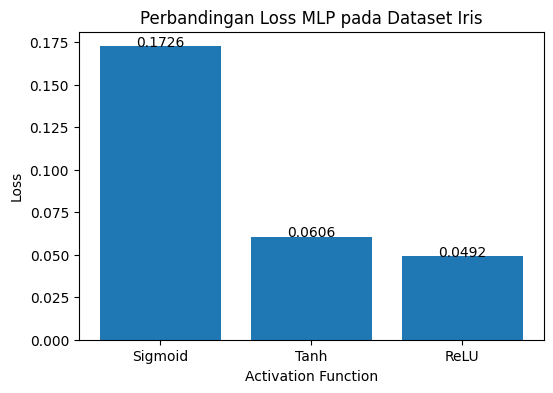

In [59]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    results_df["Activation Function"],
    results_df["Loss"]
)

plt.title("Perbandingan Loss MLP pada Dataset Iris")
plt.xlabel("Activation Function")
plt.ylabel("Loss")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f"{yval:.4f}",
        ha='center'
    )

plt.show()

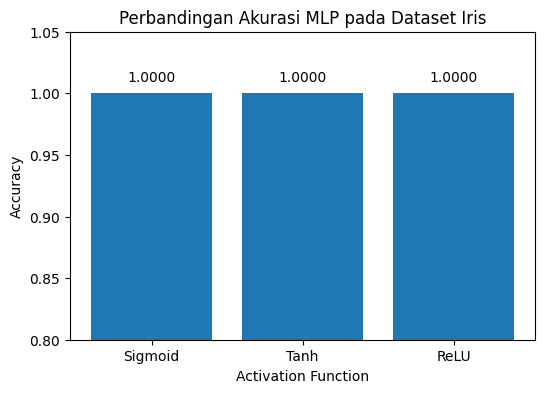

In [60]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    results_df["Activation Function"],
    results_df["Accuracy"]
)

plt.title("Perbandingan Akurasi MLP pada Dataset Iris")
plt.xlabel("Activation Function")
plt.ylabel("Accuracy")
plt.ylim(0.8,1.05)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.4f}",
        ha='center'
    )

plt.show()

Berdasarkan hasil pengujian MLP pada dataset Iris menggunakan fungsi aktivasi Sigmoid, Tanh, dan ReLU, diperoleh bahwa ketiga fungsi aktivasi menghasilkan akurasi yang sangat tinggi. Namun, nilai loss yang dihasilkan berbeda. Fungsi aktivasi ReLU memiliki nilai loss paling kecil dibandingkan Sigmoid dan Tanh, sehingga menunjukkan performa pembelajaran yang lebih baik. Oleh karena itu, pada percobaan ini fungsi aktivasi ReLU dapat dianggap sebagai fungsi aktivasi terbaik untuk dataset Iris.
